# Cosine Similarity for Music Recommendation

This notebook explores the application of Cosine Similarity in a simple music recommendation scenario.

Unlike Manhattan Distance and Euclidean Distance, which focus on absolute and geometric distance, Cosine Similarity measures similarity based on the orientation of user preference vectors.

The objective of this experiment is to investigate whether users with different numerical intensities may still be considered similar when their overall preference patterns move in the same direction.

This project also highlights the importance of vector representation, feature engineering, and similarity analysis in recommendation systems.

## Research Question

Can users with different numerical feature intensities still be considered similar if their overall preference patterns move in the same direction?

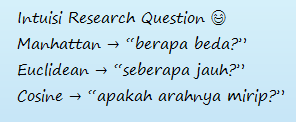

# Dataset
### Synthetic Music Preference Dataset
The dataset used in this project is a synthetic music preference dataset consisting of numerical and categorical features representing user listening characteristics.

Features included in the dataset:

- Tempo
- Energy
- Acousticness
- Danceability
- Genre
- Mood

This dataset will be used to explore how different similarity metrics produce different recommendation behaviors.

In [3]:
import pandas as pd

df = pd.read_csv("music_preferences.csv")

df.head()

,User,Tempo,Energy,Acousticness,Danceability,Genre,Mood
0,U1,8,6,3,9,Jazz,Sad
1,U2,7,5,4,8,Pop,Happy
2,U3,3,4,8,2,Jazz,Sad
3,U4,9,8,2,9,Jazz,Happy
4,U5,6,7,5,7,Pop,Sad


# Preprocessing

## Encoding Categorical Features

Cosine Similarity requires numerical vector representations. Therefore, categorical features such as Genre and Mood must be transformed into numerical format using One-Hot Encoding.

This process converts each category into binary indicator features while preserving categorical information.

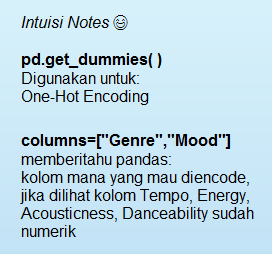 
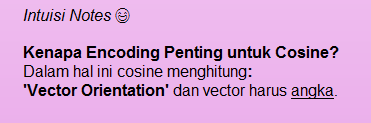

In [4]:
#One-hot Encoding (get_dummies)
df_encoded = pd.get_dummies(df, columns=["Genre","Mood"])
print(df_encoded.head())

  User  Tempo  Energy  Acousticness  Danceability  Genre_Jazz  Genre_Pop  \
0   U1      8       6             3             9        True      False   
1   U2      7       5             4             8       False       True   
2   U3      3       4             8             2        True      False   
3   U4      9       8             2             9        True      False   
4   U5      6       7             5             7       False       True   

   Genre_Rock  Mood_Chill  Mood_Happy  Mood_Sad  
0       False       False       False      True  
1       False       False        True     False  
2       False       False       False      True  
3       False       False        True     False  
4       False       False       False      True  


In [5]:
features = df_encoded.drop(columns=["User"])
features.head()

,Tempo,Energy,Acousticness,Danceability,Genre_Jazz,Genre_Pop,Genre_Rock,Mood_Chill,Mood_Happy,Mood_Sad
0,8,6,3,9,True,False,False,False,False,True
1,7,5,4,8,False,True,False,False,True,False
2,3,4,8,2,True,False,False,False,False,True
3,9,8,2,9,True,False,False,False,True,False
4,6,7,5,7,False,True,False,False,False,True


### Feature Scaling

Numerical features in the dataset exist on different value ranges. Feature scaling is applied to normalize the data and ensure that no single feature dominates the similarity calculation.

In this project, Min-Max Scaling is used to transform feature values into a range between 0 and 1.

This preprocessing step is particularly important for similarity-based methods because distance and vector calculations are highly sensitive to feature magnitude.


In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(features)

In [7]:
#Priveiw dataframe after scaling

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

,Tempo,Energy,Acousticness,Danceability,Genre_Jazz,Genre_Pop,Genre_Rock,Mood_Chill,Mood_Happy,Mood_Sad
0,0.857143,0.571429,0.250,0.888889,1.0,0.0,0.0,0.0,0.0,1.0
1,0.714286,0.428571,0.375,0.777778,0.0,1.0,0.0,0.0,1.0,0.0
2,0.142857,0.285714,0.875,0.111111,1.0,0.0,0.0,0.0,0.0,1.0
3,1.000000,0.857143,0.125,0.888889,1.0,0.0,0.0,0.0,1.0,0.0
4,0.571429,0.714286,0.500,0.666667,0.0,1.0,0.0,0.0,0.0,1.0


## Cosine Similarity Calculation

Cosine Similarity measures how similar two vectors are based on the angle between them rather than their absolute distance.

In this section, user similarity is calculated using the scaled feature vectors. Higher cosine similarity scores indicate more similar preference patterns between users.

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(scaled_df)

similarity_df = pd.DataFrame(similarity_matrix, index=df["User"], columns=df["User"])
similarity_df

User,U1,U2,U3,U4,U5,U6,U7,U8,U9,U10,...,U41,U42,U43,U44,U45,U46,U47,U48,U49,U50
User,,,,,,,,,,,,,,,,,,,,,
U1,1.000000,0.447604,0.775378,0.751583,0.703561,0.096454,0.733587,0.379198,0.525160,0.745454,...,0.342113,0.525160,0.364794,0.491378,0.404789,0.435107,0.507826,0.467015,0.323749,0.218329
U2,0.447604,1.000000,0.203041,0.713568,0.694490,0.445600,0.437332,0.667424,0.235464,0.449430,...,0.962848,0.562773,0.428054,0.695706,0.984667,0.488843,0.702917,0.706172,0.641164,0.562773
U3,0.775378,0.203041,1.000000,0.441325,0.563587,0.310512,0.452886,0.274018,0.630451,0.411788,...,0.267327,0.630451,0.637887,0.170531,0.244671,0.633477,0.134773,0.187571,0.257827,0.272763
U4,0.751583,0.713568,0.441325,1.000000,0.459217,0.066820,0.769363,0.652363,0.484127,0.777655,...,0.619427,0.769000,0.575770,0.544486,0.685454,0.659553,0.777655,0.500767,0.596386,0.484127
U5,0.703561,0.694490,0.563587,0.459217,1.000000,0.490547,0.455193,0.396833,0.254693,0.444373,...,0.668561,0.254693,0.153621,0.710189,0.699319,0.188709,0.444373,0.709927,0.333233,0.254693
U6,0.096454,0.445600,0.310512,0.066820,0.490547,1.000000,0.349567,0.226957,0.618361,0.303622,...,0.564374,0.269085,0.332205,0.625282,0.507815,0.300969,0.033122,0.704735,0.226796,0.269085
U7,0.733587,0.437332,0.452886,0.769363,0.455193,0.349567,1.000000,0.387565,0.772061,0.992435,...,0.339968,0.481194,0.311233,0.770392,0.415993,0.377603,0.541906,0.739260,0.305470,0.190327
U8,0.379198,0.667424,0.274018,0.652363,0.396833,0.226957,0.387565,1.000000,0.269808,0.370576,...,0.670843,0.608640,0.523692,0.387565,0.682919,0.557188,0.895399,0.378634,0.986201,0.947472
U9,0.525160,0.235464,0.630451,0.484127,0.254693,0.618361,0.772061,0.269808,1.000000,0.743574,...,0.265237,0.631530,0.613308,0.481194,0.251785,0.624770,0.172844,0.526757,0.262605,0.263060



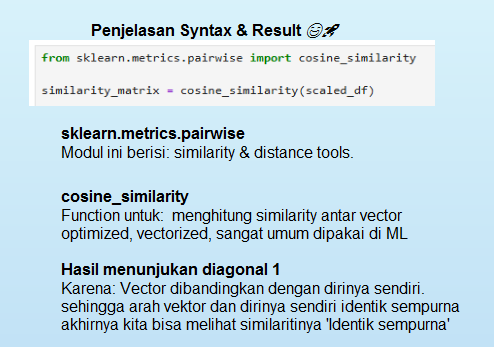

## Top-N Similar Users

To identify the most similar users to the pivot user (U1), cosine similarity scores are sorted in descending order.

Higher similarity values indicate stronger alignment in user preference patterns.

In [14]:
u1_similarity = similarity_df.loc["U1"]

u1_similarity = u1_similarity.sort_values(ascending=False)
u1_similarity = u1_similarity.drop("U1") # hapus U1 dari list
top5_users = u1_similarity.head(5)

top5_users

User
U11    0.990587
U14    0.988706
U3     0.775378
U4     0.751583
U16    0.749927
Name: U1, dtype: float64

## Cosine Similarity Heatmap

The heatmap below visualizes pairwise cosine similarity scores between users.

Brighter values indicate stronger similarity relationships, while darker values represent weaker alignment between user preference vectors.

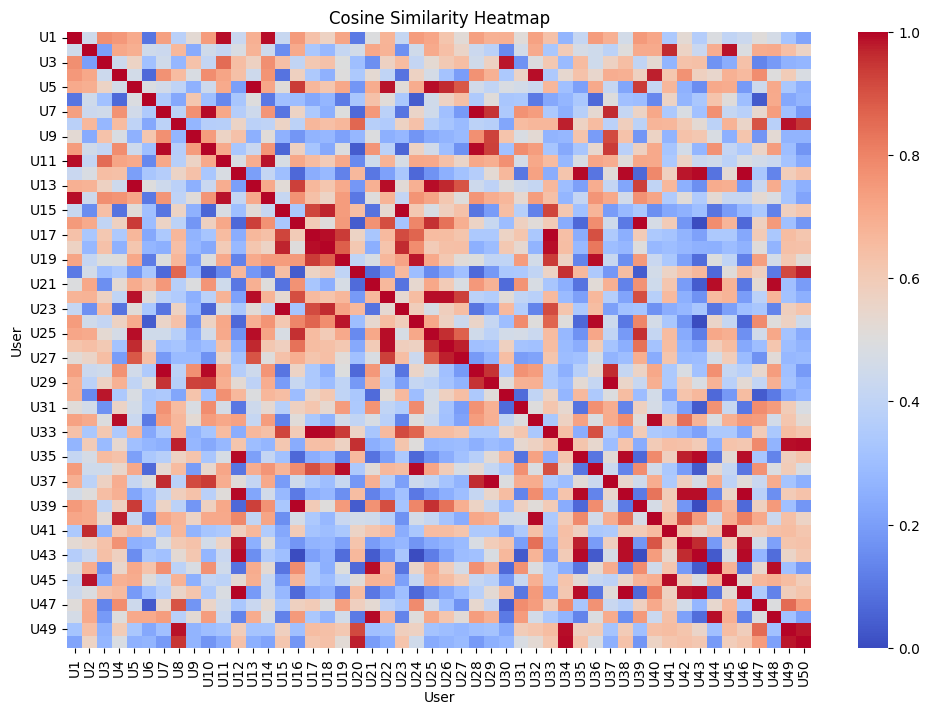

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(similarity_df, annot=False, cmap="coolwarm")
plt.title("Cosine Similarity Heatmap")
plt.savefig(
    "cosine_similarity_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Result and Analysis

After applying Cosine Similarity to the scaled music preference dataset, several important patterns were observed.

The similarity ranking shows that U11 and U14 have the highest similarity scores relative to the pivot user (U1), with similarity values approaching 1.0. This indicates that these users share highly aligned preference patterns, even if minor differences exist in their numerical feature values.

Interestingly, users such as U3 still maintain relatively high similarity scores despite having noticeable differences in several numerical attributes. This behavior highlights one of the key characteristics of Cosine Similarity: the method focuses more on vector orientation and preference direction rather than absolute numerical distance.

Compared to Manhattan Distance and Euclidean Distance, Cosine Similarity appears to produce a more pattern-oriented interpretation of similarity. Users with aligned listening tendencies may still be considered similar even when their feature magnitudes differ.

The heatmap visualization further reveals that similarity relationships are not distributed randomly across the dataset. Several local regions with stronger similarity intensity can be observed, suggesting the possible existence of preference communities or similarity clusters among users.

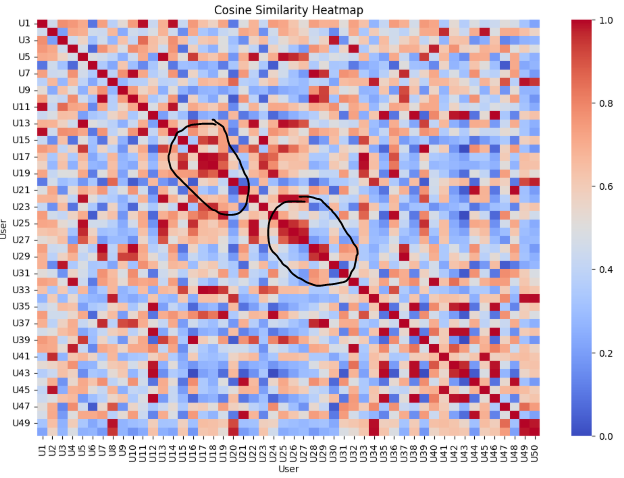

## Additional Findings

One particularly interesting observation from the heatmap visualization is the appearance of localized high-similarity regions.

These regions may indicate the presence of small groups of users with highly aligned music preference patterns. In recommendation system analysis, this phenomenon is often associated with similarity communities or local preference clusters.

Although formal clustering algorithms were not applied in this project, the visualization suggests that certain users naturally form similarity-based group structures.

This finding demonstrates how pairwise similarity analysis can provide early intuition about hidden relational structures within user preference data.

The probability of similarity clusters emerging increases when multiple users share consistent feature orientations across both numerical and categorical attributes. Since Cosine Similarity emphasizes vector direction, users with aligned preference structures naturally form denser similarity relationships within the matrix representation.

# Future Improvements
- KNN,
- embeddings,
- real-world datasets,
- Spotify API,
- context-aware recommendation